# **Deep Learning and CNN for Computer Vision, Hokkaido University**

## Day 2, Notebook -2: Solving Overfitting Problem, and Regularization

In this session you will be implementing regularization to avoid overfitting.

So lets get started!

## Tutorial:
Implementation of a  CNN architecture using Keras for classfication of Cats/Dogs Dataset from Kaggle.

## Tasks for this week:

1. Implementation of Neural Network for Dogs and Cats classification using Keras API.
2. Train and test model and identify overfitting.
3. Data augmentation and Drop outs


### Step 1: Import and required packages

we will need tensorflow, numpy, os and keras


In [ ]:
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
print(tf.__version__)

2.20.0


### Step 2: Download the Cats & Dogs dataset

In [ ]:
!wget --no-check-certificate \
    https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip \
    -O /tmp/cats_and_dogs_filtered.zip

--2026-07-05 13:03:17--  https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.199.207, 74.125.142.207, 74.125.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.199.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M   163MB/s    in 0.4s    

2026-07-05 13:03:17 (163 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [ ]:
local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

base_dir = '/tmp/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Directory with our training cat pictures
train_cats_dir = os.path.join(train_dir, 'cats')

# Directory with our training dog pictures
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Directory with our validation cat pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')

# Directory with our validation dog pictures
validation_dogs_dir = os.path.join(validation_dir, 'dogs')


### Step 3:  Design the CNN Architecture

Design the following CNN architecture:

<img src='http://drive.google.com/uc?export=view&id=1EAWFwp7T92q3Lm1ZrX9A2-wnvhfAfzSF' alt='Conv'>

Input: $150 X 150 X 3$ image

No. of filters, filter size:
- Conv1 : 32, 3x3
- Conv2 : 64, 3x3
- Conv3 : 128, 3x3
- Conv4 : 128, 3x3

Activation function in CONV layer: Relu

Pool: MaxPooling, 2x2

Activation function in Output layer : sigmoid, 2 classes

**Hint:** Use Conv2D(), MaxPooling2D(), Flatten(), and Dense()

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'])

### Step 4:  Training CNN with ImageDataGenerator

In [ ]:
# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
history = model.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=100,
      validation_data=validation_generator,
      validation_steps=50,  # 1000 images = batch_size * steps
      verbose=2)

Epoch 1/100
100/100 - 12s - 118ms/step - acc: 0.5185 - loss: 0.6937 - val_acc: 0.5080 - val_loss: 0.6834
Epoch 2/100
100/100 - 4s - 45ms/step - acc: 0.5680 - loss: 0.6778 - val_acc: 0.5750 - val_loss: 0.6734
Epoch 3/100
100/100 - 5s - 51ms/step - acc: 0.6035 - loss: 0.6593 - val_acc: 0.5870 - val_loss: 0.6698
Epoch 4/100
100/100 - 4s - 44ms/step - acc: 0.6415 - loss: 0.6359 - val_acc: 0.5880 - val_loss: 0.6692
Epoch 5/100
100/100 - 4s - 43ms/step - acc: 0.6690 - loss: 0.6058 - val_acc: 0.6060 - val_loss: 0.6297
Epoch 6/100
100/100 - 5s - 50ms/step - acc: 0.6870 - loss: 0.5739 - val_acc: 0.5950 - val_loss: 0.6618
Epoch 7/100
100/100 - 4s - 44ms/step - acc: 0.7135 - loss: 0.5508 - val_acc: 0.6980 - val_loss: 0.5744
Epoch 8/100
100/100 - 6s - 64ms/step - acc: 0.7280 - loss: 0.5266 - val_acc: 0.6890 - val_loss: 0.5923
Epoch 9/100
100/100 - 4s - 44ms/step - acc: 0.7400 - loss: 0.5161 - val_acc: 0.7110 - val_loss: 0.5553
Epoch 10/100
100/100 - 4s - 43ms/step - acc: 0.7550 - loss: 0.4918 - va

### Step 5:  Visualization of results and identification of overfitting

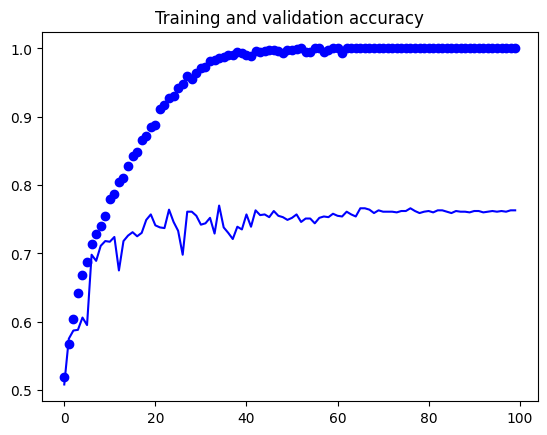

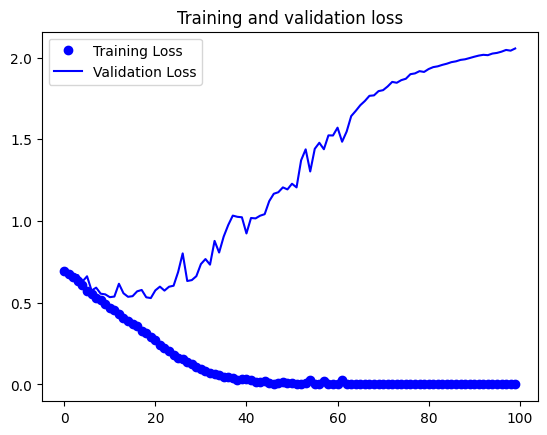

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

### Step 6:  Design of CNN for data augmentation

In [ ]:
model_data_aug = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


### Step 7:  Using ImageDataGenerator for data augmentation

In [ ]:
# This code has changed. Now instead of the ImageGenerator just rescaling
# the image, we also rotate and do other operations
# Updated to do image augmentation
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
model_data_aug.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'])

history = model_data_aug.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=100,
      validation_data=validation_generator,
      validation_steps=50,  # 1000 images = batch_size * steps
      verbose=2)

Epoch 1/100
100/100 - 19s - 186ms/step - acc: 0.5020 - loss: 0.6934 - val_acc: 0.5450 - val_loss: 0.6869
Epoch 2/100
100/100 - 15s - 153ms/step - acc: 0.5380 - loss: 0.6859 - val_acc: 0.5020 - val_loss: 0.6790
Epoch 3/100
100/100 - 16s - 156ms/step - acc: 0.5745 - loss: 0.6750 - val_acc: 0.6150 - val_loss: 0.6544
Epoch 4/100
100/100 - 23s - 225ms/step - acc: 0.5870 - loss: 0.6645 - val_acc: 0.6420 - val_loss: 0.6367
Epoch 5/100
100/100 - 16s - 155ms/step - acc: 0.5970 - loss: 0.6632 - val_acc: 0.6060 - val_loss: 0.6462
Epoch 6/100
100/100 - 16s - 156ms/step - acc: 0.6000 - loss: 0.6531 - val_acc: 0.6730 - val_loss: 0.6207
Epoch 7/100
100/100 - 17s - 168ms/step - acc: 0.6355 - loss: 0.6347 - val_acc: 0.5520 - val_loss: 0.6875
Epoch 8/100
100/100 - 16s - 158ms/step - acc: 0.6370 - loss: 0.6271 - val_acc: 0.6950 - val_loss: 0.5867
Epoch 9/100
100/100 - 15s - 151ms/step - acc: 0.6615 - loss: 0.6154 - val_acc: 0.6760 - val_loss: 0.5862
Epoch 10/100
100/100 - 15s - 152ms/step - acc: 0.6670 -

### Step 8:  Visualization the results

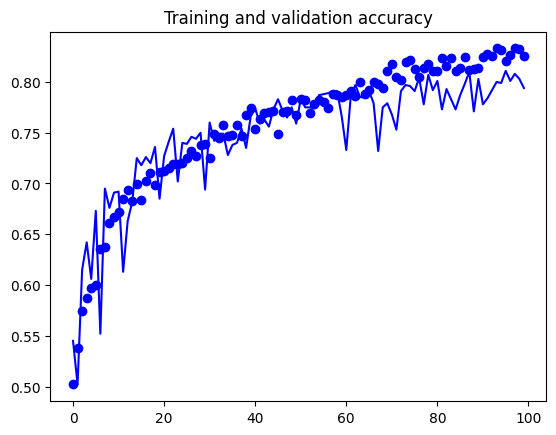

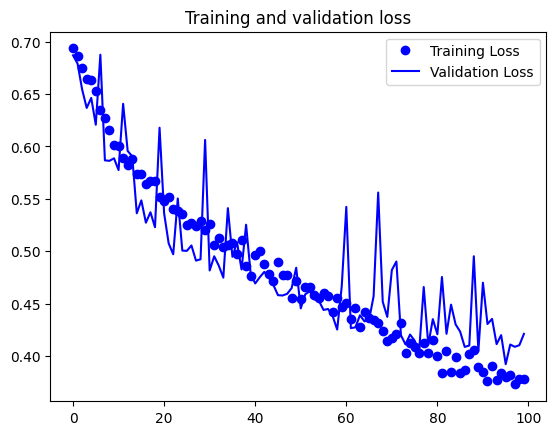

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

### Step 9:  Using drop outs and data augmentation

In [ ]:
model_drop_out = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.5), #Adding Dropout
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_drop_out.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4),
              metrics=['acc'])

# This code has changed. Now instead of the ImageGenerator just rescaling
# the image, we also rotate and do other operations
# Updated to do image augmentation
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

history = model_drop_out.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=100,
      validation_data=validation_generator,
      validation_steps=50,  # 1000 images = batch_size * steps
      verbose=2)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/100
100/100 - 20s - 196ms/step - acc: 0.5130 - loss: 0.6937 - val_acc: 0.5100 - val_loss: 0.6855
Epoch 2/100


KeyboardInterrupt: 

### Step 10:  Visualization of results

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## Optional:

Try changing the Regularization to L1 and L2 and check output

Hint:

**L1** : tf.keras.regularizers.l1(l=0.01)

**L2**: tf.keras.regularizers.l2(l=0.01)

Reference: https://keras.io/regularizers/